# Feature Evaluation - CME Futures

One screening pass over every candidate feature the two upstream notebooks built,
against the forward return the case study is trying to predict. For each feature it
asks three questions in order. Can the value be trusted at the moment a decision is
made? Does it sort next week's returns better than chance would? And is that sorting
the same in every year of the walk-forward test, or the product of one good period?

The answers become one record per feature. This notebook chooses nothing: it does not
fit a model, it does not pick the feature set the training notebooks use, and it says
nothing about whether a strategy built on these features would make money. Chapter 7
is explicit that screening features one at a time is necessary and not sufficient.

**What it reads**: `features/financial.parquet` (built by `03_financial_features`),
`features/model_based.parquet` (built by `04_model_based_features`), the forward-return
labels under `labels/` (built by `02_labels`), and `config/setup.yaml` for the label
names, the walk-forward geometry and the date the holdout begins.

**What it writes**: `evaluation/triage_ledger.parquet`, one row per feature carrying
its decision and the evidence behind it, and `evaluation/ic_timeseries.parquet`, the
per-date correlation series the figures here are drawn from.

**Learning objectives**:

- Measure how well a feature sorts next week's returns, by correlating the rank of the
  feature with the rank of the return across the products quoted on each decision date,
  then averaging that correlation over dates.
- Widen the error bars on that average to allow for consecutive dates being computed
  from price windows that overlap, so the daily measurements are not independent of
  each other and there are fewer of them than there appear to be.
- Correct for having tested every candidate feature at once rather than one, using
  Benjamini-Hochberg control of the share of announced findings that are false.
- Split a feature's results by walk-forward validation year, to tell one that works
  throughout the sample from one carried by a single period.
- Record a keep, revisit or drop decision per feature - the book calls these PROCEED,
  REVISE and STOP - together with the evidence that produced it.

**Book reference**: Chapter 7, Section 7.3 (Univariate feature-label evaluation) and
Section 7.4 (Search accounting and multiple testing). Section 8.6 covers controlling
the search once features are combined rather than screened one at a time.

**Prerequisites**: run `03_financial_features` and `04_model_based_features` first.

In [1]:
"""Feature Evaluation - CME Futures.

Screens the financial and model-based features against the primary forward-return
label and writes one triage record per feature.
"""

import re
from datetime import date

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from IPython.display import display
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import (
    compute_ic_hac_stats,
    compute_ic_uncertainty,
    cross_sectional_ic_series,
)
from plotly.subplots import make_subplots
from scipy.stats import spearmanr

from utils.artifact_specs import load_setup_config, resolve_label_buffer
from utils.cv_splits import generate_cv_splits
from utils.data_quality import validate_modeling_inputs
from utils.paths import display_path, get_case_study_dir
from utils.style import COLORS, GRAY_FILLS

In [2]:
MAX_SYMBOLS = 0

## Configuration

The label, the horizon it looks forward over and the date the holdout begins are read
from `config/setup.yaml`, which is also what the training notebooks read, so the two
cannot drift apart on which return is being predicted. The thresholds below are
choices this notebook makes. Each is bound once, and the value is not repeated in
prose or in a figure title, because a threshold written twice is a decision with two
sources of truth. What each one decides:

- **Coverage** and **staleness** are the two correctness gates. A feature must have a
  value on most of the rows it is screened on, and must not simply repeat the previous
  session's number on most of them. A feature that is mostly absent cannot be ranked
  on, and one that rarely moves cannot separate this week's products from last week's.
- **The false-discovery level** is the share of the features this notebook calls
  significant that we are willing to have be noise.
- **The exploration bar** is a pair of conditions. A feature that is not significant on
  its own is still carried forward if it points the same way in most of the validation
  years and its average correlation clears a floor. A rank correlation is unitless and
  does not convert into a return, so the floor is a judgement about how weak an
  association can be and still be worth carrying into a strategy that pays commission,
  bid-ask spread and roll slippage. It is a stated choice rather than an estimate, and
  Section 6 says what follows from that.
- **The redundancy cut** is the correlation above which two features are reported as
  one piece of evidence rather than two.
- **The minimum cross-section** is how many products must carry both a feature value
  and a label on a date before that date's correlation is used at all. A rank
  correlation over a handful of products is mostly noise. It is capped by the universe
  actually loaded, so a run over a reduced universe narrows the gate with it rather
  than silently discarding every date.
- **The extreme-value limits** are what the quality gate treats as impossible rather
  than merely large: a weekly futures return above the return limit is a failure of
  the back-adjustment that stitches consecutive contracts into one price series, not a
  market move.

In [3]:
CASE_STUDY_ID = "cme_futures"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

SETUP = load_setup_config(CASE_STUDY_ID)
eval_config = SETUP["evaluation"]
SECTORS = {
    product: sector
    for sector, products in SETUP["universe"]["product_groups"].items()
    for product in products
}

PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = resolve_label_buffer(CASE_STUDY_ID, PRIMARY_LABEL, SETUP)
assert LABEL_BUFFER, f"No label buffer configured for {PRIMARY_LABEL}"


def horizon_sessions(buffer_spec: str) -> int:
    """Sessions a label looks forward over, from its `setup.yaml` buffer."""
    return int(re.match(r"^(\d+)", buffer_spec).group(1))


PRIMARY_HORIZON = horizon_sessions(LABEL_BUFFER)
# The bandwidth of the serial-correlation correction is the label horizon, because that
# is the overlap a daily-sampled forward return induces. Deriving it here rather than
# typing it keeps the correction and the label from drifting apart.
HAC_MAXLAGS = PRIMARY_HORIZON
# Every forward return the case study declares, primary first, for the horizon profile.
LABEL_HORIZONS = {PRIMARY_LABEL: PRIMARY_HORIZON} | {
    name: horizon_sessions(spec) for name, spec in SETUP["labels"]["variant_buffers"].items()
}

FDR_ALPHA = 0.05  # Benjamini-Hochberg level
NAIVE_T = 1.96  # two-sided normal critical value, both significance tiers are read against
REDUNDANCY_CUT = 0.7  # |rho| above which two features are reported as one piece of evidence
MIN_SIGN_CONSISTENCY = 0.60  # fold-sign agreement the exploration arm requires
IC_THRESHOLD = 0.008  # |IC| the exploration arm requires, at a weekly horizon
N_QUANTILES = 5
MIN_COVERAGE = 0.70  # non-null fraction the correctness gate requires
MAX_STALENESS = 0.50  # unchanged-from-prior-date fraction the correctness gate allows
MAX_ABS_RETURN = 1.0  # a weekly futures return past this is a back-adjustment failure
MAX_ABS_FEATURE = 1e6  # feature magnitude past this is a construction failure, not a value
CROSS_SECTION_TARGET = 10  # products a date needs before its rank correlation is used
MIN_IC_DATES = 20  # dates a feature needs before its IC series is summarized at all
MIN_FOLD_DATES = 5  # dates a fold must contribute before its mean IC is read
LEADING_FOR_SERIES = 3  # features the IC-through-time figure draws, by |IC|
ROLLING_DAYS = 126  # sessions in the rolling mean drawn over the IC series, about half a year
RANKED_SHOWN = 25  # features the ranking figure draws
FOLDS_SHOWN = 12  # features the fold-stability figure draws
HORIZON_SHOWN = 8  # features the horizon profile draws
SHAPE_SHOWN = 6  # features the quantile-profile figure draws
TOP_PAIRS = 15  # correlated pairs the redundancy figure ranks

## The data this screen runs on

Three upstream artifacts are combined into one table with a row per product per
session: the price-derived features from `features/financial.parquet`, the
model-derived features from `features/model_based.parquet`, and the forward return
from `labels/`. Every candidate feature is a column, and the label is the column each
one is measured against.

**One contract per product.** A futures product does not trade as a single
instrument. On any day the exchange lists several delivery months of the same
underlying, and the pipeline tracks three of them: the *front month*, the contract
nearest to delivery and the most heavily traded, and the two behind it, the first and
second *deferred*. This screen keeps the front month alone. The three contracts on one
product are three views of the same market, so keeping all of them would present the
rank correlation with roughly ninety entities per date when there are only thirty
independent ones, and a correlation across near-duplicate rows looks more reliable
than it is.

**The holdout stays unread.** Everything computed below is an input to which features
the later notebooks work with, which is a form of selection. `config/setup.yaml` names
the date the holdout starts; no row on or after it is loaded into any statistic here,
so the holdout is still untouched when it is used, once, to confirm or disconfirm the
final result.

**Which rows the model-derived features are read on.** `model_based.parquet` carries a
`fold` column: the walk-forward test fits its estimators separately for each fold, so
a value on one date exists once per fold. Two of the three families in that file are
fitted, and a fitted value is out of sample only inside its own fold's validation
window - outside it, the estimator that produced the number was fitted on a window
containing the date it sits on. Those columns are therefore read only inside the
validation window of the fold that produced them. The third family carries no fitted
parameter and holds the same values in every fold, which the cell below asserts rather
than assumes, and is then read once.

That fixes the rows for everything else too. The screen runs on the union of the five
validation windows rather than on the whole span before the holdout, and the
price-derived features are measured on the same rows as the model-derived ones. Two
reasons. On the full span a fold-fitted feature would be present only on the share of
dates the folds happen to cover, and the coverage gate below would read that design
property as a broken feature. And a correlation measured over the whole span is not
comparable with one measured over the validation windows alone, so a ranking that
mixed the two would rank the window as much as the feature.

In [4]:
features = pl.read_parquet(CASE_DIR / "features" / "financial.parquet").filter(
    pl.col("position") == 0
)
temporal = pl.read_parquet(CASE_DIR / "features" / "model_based.parquet").filter(
    pl.col("position") == 0
)
label_df = pl.read_parquet(CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet").filter(
    pl.col("position") == 0
)
label_col = [c for c in label_df.columns if c not in ("timestamp", "product", "position")][0]

HOLDOUT_START = date(*map(int, eval_config["holdout_start"].split("-")))

# position is fixed at 0 throughout, and kept in the key so every join below is on the
# same three columns the artifacts are written with.
JOIN_COLS = ["timestamp", "product", "position"]
DATE_COL = "timestamp"

### The universe

The thirty products the screen ranks against each other, grouped the way the exchange
and the trading desk group them. This is what "the cross-section" means in every
statistic below: on a given session, each product contributes one feature value and
one forward return, and the correlation is taken across the rows of this table.

Two things in it matter for what follows. The sectors differ in how many products they
contain, so a sector with more products moves the cross-sectional ranking more than
one with fewer, whatever the economics. And the first session differs across products,
so the early years of the panel rank fewer products than the late ones.

In [5]:
universe = (
    label_df.with_columns(pl.col("product").replace_strict(SECTORS).alias("sector"))
    .group_by("sector", "product")
    .agg(pl.col(DATE_COL).min().alias("start"))
    .group_by("sector")
    .agg(
        pl.len().alias("n_products"),
        pl.col("product").sort().str.join(" ").alias("products"),
        pl.col("start").min().alias("earliest_start"),
        pl.col("start").max().alias("latest_start"),
    )
    .sort("sector")
)
with pl.Config(tbl_rows=universe.height, tbl_width_chars=170, fmt_str_lengths=40):
    display(universe)

sector,n_products,products,earliest_start,latest_start
str,u32,str,date,date
"""agriculture""",5,"""ZC ZL ZM ZS ZW""",2011-01-03,2011-01-03
"""currencies""",6,"""6A 6B 6C 6E 6J 6S""",2011-01-03,2011-01-03
"""energy""",4,"""CL HO NG RB""",2011-01-03,2011-01-03
"""equity_index""",4,"""ES NQ RTY YM""",2011-01-03,2017-07-10
"""livestock""",3,"""GF HE LE""",2011-01-03,2011-01-03
"""metals""",4,"""GC HG PL SI""",2011-01-03,2011-01-03
"""treasuries""",4,"""ZB ZF ZN ZT""",2011-01-03,2011-01-03


### The walk-forward folds

*Walk-forward* means the sample is cut into consecutive blocks, each with an earlier
training window and a later validation window that the training window never reaches
into, so a feature is always judged on dates after the ones any estimator saw. The
boundaries come from `generate_cv_splits`, which reads them out of `config/setup.yaml`
and is the same call every other notebook in this pipeline makes. They are derived
here rather than copied, because the fold numbers printed below have to mean the same
thing as the fold numbers stored in `model_based.parquet` for the join further down to
be sound.

The gap between a training window's end and its validation window's start is the label
horizon. Without it, the last training dates would carry a return that resolves after
validation begins, and the estimator would have seen part of what it is about to be
tested on. The same reasoning ends each validation window short of the holdout: a
decision made on the last validation date has to have its return observable before the
holdout period starts, so the last few sessions of the final fold are dropped.

In [6]:
splits = generate_cv_splits(
    label_df.select(DATE_COL).unique().sort(DATE_COL),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
)


def _as_date(value) -> date:
    return pd.Timestamp(value).date()


display(
    pl.DataFrame(
        [
            {
                "fold": split["fold"],
                "train_start": _as_date(split["train_start"]),
                "train_end": _as_date(split["train_end"]),
                "val_start": _as_date(split["val_start"]),
                "val_end": _as_date(split["val_end"]),
            }
            for split in splits
        ]
    ).sort("fold")
)

fold,train_start,train_end,val_start,val_end
i64,date,date,date,date
0,2015-01-05,2022-12-22,2023-01-03,2023-12-21
1,2014-01-03,2021-12-23,2022-01-03,2022-12-30
2,2013-01-01,2020-12-24,2021-01-05,2021-12-31
3,2012-01-04,2019-12-26,2020-01-06,2021-01-04
4,2011-01-05,2018-12-26,2019-01-04,2020-01-03


### Reading each model-derived feature where it is out of sample

The columns whose names begin with a fitted family's prefix are kept only on the dates
inside their own fold's validation window; the rest are asserted to be identical
across folds and read once. The assertion is what makes the second half safe: if a
column that is supposed to carry no fitted parameter ever started to depend on the
fold, this cell would stop rather than quietly average two different quantities.

In [7]:
FITTED_PREFIXES = ("arima_", "hmm_")
# The artifact as written, one row per key and fold. The quality gate below reads this
# rather than the resolved frame, because every fold's value is a value the training
# notebooks can read, and the resolved frame has dropped most of them.
temporal_artifact = temporal
temporal_feature_cols = [c for c in temporal.columns if c not in (*JOIN_COLS, "fold")]
invariant_cols = [c for c in temporal_feature_cols if not c.startswith(FITTED_PREFIXES)]
fitted_cols = [c for c in temporal_feature_cols if c.startswith(FITTED_PREFIXES)]

folds = sorted(temporal["fold"].unique().to_list())
_reference = temporal.filter(pl.col("fold") == folds[0]).select([*JOIN_COLS, *invariant_cols])
for fold_id in folds[1:]:
    other = temporal.filter(pl.col("fold") == fold_id).select([*JOIN_COLS, *invariant_cols])
    assert _reference.sort(JOIN_COLS).equals(other.sort(JOIN_COLS)), (
        f"fold {fold_id} disagrees with fold {folds[0]} on {invariant_cols}, "
        "which this notebook reads once because they carry no fitted parameter"
    )

val_windows = {int(s["fold"]): (_as_date(s["val_start"]), _as_date(s["val_end"])) for s in splits}
IN_VALIDATION = pl.any_horizontal(
    [(pl.col(DATE_COL) >= start) & (pl.col(DATE_COL) <= end) for start, end in val_windows.values()]
)
fitted_oos = (
    temporal.select([*JOIN_COLS, "fold", *fitted_cols])
    .filter(
        pl.col("fold").replace_strict(
            {f: start for f, (start, _) in val_windows.items()}, default=None
        )
        <= pl.col(DATE_COL),
    )
    .filter(
        pl.col(DATE_COL)
        <= pl.col("fold").replace_strict(
            {f: end for f, (_, end) in val_windows.items()}, default=None
        )
    )
    .drop("fold")
)
assert fitted_oos.select(JOIN_COLS).is_duplicated().sum() == 0, (
    "validation windows overlap; a fitted feature would take two values on one date"
)
temporal = _reference.join(fitted_oos, on=JOIN_COLS, how="left")

### Assembling the table

`ls_signal` and `risk_adj_score` are dropped: they are the case study's own composite
trading signals, built downstream from several of the columns beside them, so scoring
them here would measure the combination rather than a candidate input to it.

In [8]:
COMPOSITE_COLS = ["ls_signal", "risk_adj_score"]
METADATA_COLS = {*JOIN_COLS, *COMPOSITE_COLS}
financial_cols = [c for c in features.columns if c not in METADATA_COLS]
temporal_cols = [c for c in temporal.columns if c not in JOIN_COLS]
all_feature_cols = financial_cols + temporal_cols

eval_panel = (
    features.drop(COMPOSITE_COLS, strict=False)
    .join(temporal, on=JOIN_COLS, how="left")
    .join(label_df, on=JOIN_COLS, how="inner")
    # The holdout first, then the validation windows, which is what every screen reads.
    .filter(pl.col(DATE_COL) < HOLDOUT_START)
    .filter(IN_VALIDATION)
)
assert eval_panel[DATE_COL].max() < HOLDOUT_START

# Reduce the universe for a fast development run. Left at zero, every product is kept.
if MAX_SYMBOLS > 0:
    top = eval_panel.group_by("product").len().sort("len", descending=True).head(MAX_SYMBOLS)
    eval_panel = eval_panel.filter(pl.col("product").is_in(top["product"]))

n_rows = len(eval_panel)
n_symbols = eval_panel["product"].n_unique()
n_dates = eval_panel[DATE_COL].n_unique()
# A rank correlation over a handful of products is mostly noise, so a date has to carry
# a minimum cross-section to count. Capping it by the universe actually loaded means a
# reduced run measures something rather than discarding every date.
MIN_CROSS_SECTION = min(CROSS_SECTION_TARGET, n_symbols)

print(f"Screening {len(all_feature_cols)} features against {label_col}")
print(
    f"  {n_rows:,} product-sessions, {n_symbols} products, {n_dates} sessions, "
    f"{eval_panel[DATE_COL].min()} to {eval_panel[DATE_COL].max()}"
)
print(f"  {len(financial_cols)} price-derived, {len(temporal_cols)} model-derived")
print(f"  a session counts once at least {MIN_CROSS_SECTION} products carry both columns")

Screening 69 features against fwd_ret_5d
  38,244 product-sessions, 30 products, 1285 sessions, 2019-01-04 to 2023-12-21
  60 price-derived, 9 model-derived
  a session counts once at least 10 products carry both columns


## 0. Data quality gate

Before asking whether a feature predicts anything, check that the numbers are numbers:
no infinities, no column that is entirely absent, no return so large it can only be a
construction failure. The failures this catches are silent ones. A division by zero in
a derived feature or a break in the back-adjustment that stitches consecutive delivery
months into one continuous price series does not raise anything here; it surfaces
several notebooks later as an unexplained loss or a model that refuses to fit.

**This gate reads more rows than the screens below do, deliberately.** The screens are
a selection decision and run on the validation windows, where every candidate exists.
This gate asks whether the artifact is sound at all, and the rows the training
notebooks read include every fold's training window back to the start of the panel, so
a broken value there reaches a model whether or not this notebook screened it. It
therefore runs on the whole span before the holdout. It stops there for two reasons:
its counts are printed, so reading holdout rows would put a description of the holdout
into this notebook's output, and it is allowed to halt the run, which would make
whether this notebook executes depend on data it is not permitted to see.

In [9]:
sealed_features = features.filter(pl.col(DATE_COL) < HOLDOUT_START)
# The fold-bearing artifact rather than the resolved frame, for the reason in the
# markdown above: every fold's value is a value a training notebook can read.
sealed_temporal = temporal_artifact.filter(pl.col(DATE_COL) < HOLDOUT_START)
sealed_labels = label_df.filter(pl.col(DATE_COL) < HOLDOUT_START)

print("Price-derived features and the label:")
quality_result = validate_modeling_inputs(
    features_df=sealed_features,
    label_df=sealed_labels,
    feature_cols=[c for c in features.columns if c not in set(JOIN_COLS)],
    label_col=label_col,
    join_cols=JOIN_COLS,
    asset_col="product",
    max_abs_return=MAX_ABS_RETURN,
    max_abs_feature=MAX_ABS_FEATURE,
    fail_on_critical=True,
)

print("Model-derived features, every fold, and the label:")
temporal_quality = validate_modeling_inputs(
    features_df=sealed_temporal,
    label_df=sealed_labels,
    feature_cols=temporal_cols,
    label_col=label_col,
    join_cols=JOIN_COLS,
    asset_col="product",
    max_abs_return=MAX_ABS_RETURN,
    max_abs_feature=MAX_ABS_FEATURE,
    fail_on_critical=True,
)

Price-derived features and the label:
Data Quality Gate: ALL CLEAR
Model-derived features, every fold, and the label:
Data Quality Gate: ALL CLEAR


## 1. Can the value be trusted at decision time?

Two properties are checked per feature, and both are about whether the column can
carry a ranking at all rather than about whether it predicts anything.

**Coverage** is the share of rows where the feature has a value. A product with no
value on a date cannot be placed in that date's ranking, so a sparse feature is
ranking a shifting subset of the universe and its correlation is not comparable with
one measured on the full cross-section.

**Staleness** is the share of rows where the value repeats the same product's previous
session. A feature that rarely changes ranks this week's products almost exactly as it
ranked last week's, so whatever it appears to predict it predicts by persistence.
Slow-moving is not the same as broken - a quarterly quantity is legitimately flat
between releases - but at a weekly decision cadence a column that almost never moves
cannot be the thing that distinguishes one week from the next.

A feature failing either is recorded as STOP and takes no further part.

The book names four correctness checks at this point in the pipeline. These are two of
them. The other two - whether a feature's timestamp is the moment its information was
available, and whether the feature and the label are restricted to the same eligible
rows - are settled where the columns are built, in `03_financial_features` and
`04_model_based_features`, and cannot be re-derived from the artifacts they write.

Both are measured on the validation windows, so a feature fitted per fold is judged
over the rows where it is out of sample rather than over a span where it does not
exist.

In [10]:
coverage = {}
staleness = {}
for feat in all_feature_cols:
    coverage[feat] = eval_panel[feat].drop_nulls().len() / n_rows
    ordered = eval_panel.select(["product", DATE_COL, feat]).sort(["product", DATE_COL])
    unchanged = ordered.with_columns(
        (pl.col(feat) == pl.col(feat).shift(1).over("product")).alias("unchanged")
    )["unchanged"].sum()
    # One row per product has no predecessor, so those rows are out of the denominator.
    staleness[feat] = float(unchanged) / max(n_rows - n_symbols, 1)

correctness = {
    feat: coverage[feat] >= MIN_COVERAGE and staleness[feat] <= MAX_STALENESS
    for feat in all_feature_cols
}

n_pass = sum(correctness.values())
n_fail = len(correctness) - n_pass
print(f"Correctness gate: {n_pass} pass, {n_fail} fail")

if n_fail > 0:
    fail_df = (
        pl.DataFrame(
            {
                "feature": [f for f, ok in correctness.items() if not ok],
                "coverage": [coverage[f] for f, ok in correctness.items() if not ok],
                "staleness": [staleness[f] for f, ok in correctness.items() if not ok],
            }
        )
        .with_columns(
            pl.when(pl.col("coverage") < MIN_COVERAGE)
            .then(pl.lit("coverage"))
            .otherwise(pl.lit("staleness"))
            .alias("failed_on")
        )
        .sort(["failed_on", "feature"])
    )
    with pl.Config(tbl_rows=fail_df.height, fmt_str_lengths=40):
        display(fail_df)

Correctness gate: 54 pass, 15 fail


feature,coverage,staleness,failed_on
str,f64,f64,str
"""curvature_21d""",0.641852,0.000052,"""coverage"""
"""carry_rank_sector""",0.9795,0.635003,"""staleness"""
"""carry_regime_num""",0.9795,0.820956,"""staleness"""
"""fft_dominant_period""",0.9795,0.945701,"""staleness"""
"""is_seasonal_sector""",1.0,1.0,"""staleness"""
"""mom_rank_252d""",1.0,0.510337,"""staleness"""
"""month_cos""",1.0,0.953682,"""staleness"""
"""month_sin""",1.0,0.953682,"""staleness"""
"""quarter""",1.0,0.985084,"""staleness"""


## 2. Does the feature sort next week's returns?

The measure is the **information coefficient**, or IC: on each session, rank the
products by the feature, rank the same products by the return they went on to earn,
and take the correlation between the two rankings. That gives one number per session,
and the series of those numbers is the object this section summarizes. Ranks rather
than raw values, because what a long-short book acts on is the order of the products,
not the distance between them, and because a single outsized futures return would
otherwise dominate the statistic.

The series is computed by `cross_sectional_ic_series`, which pairs the feature and the
label on both the session and the product, so a session's correlation is taken across
that session's cross-section and nothing else. A session where too few products carry
both columns is dropped, as is one where the feature is the same for every product,
because a correlation needs the feature to vary across the things being ranked.

### Why the average of that series needs a wider error bar than it looks like it needs

The label looks forward over several sessions, and it is measured on every session, so
two consecutive observations are computed from price windows that overlap almost
entirely. They are close to the same measurement made twice. A standard error that
treats them as independent therefore counts far more information than the sample
holds. Newey-West standard errors correct for exactly this, by estimating how much the
series correlates with itself at each lag up to a chosen bandwidth and inflating the
error bar accordingly:

$$N_{\text{eff}} \approx \frac{N}{1 + 2\sum_{k=1}^{q} w_k \hat{\rho}_k}$$

where $w_k$ are Bartlett kernel weights and $\hat{\rho}_k$ are the estimated
autocorrelations. With a label spanning $h$ overlapping sessions the effective sample
is roughly $N / h$, so an uncorrected standard error understates the true one by about
$\sqrt{h}$. The bandwidth is the label horizon, taken from the same configuration
entry that decides the label, so the two cannot drift apart.

The three counts printed below are a different quantity from the error bars: they say
how many features clear a fixed t-statistic under each correction. They fall as the
correction gets stricter, but not in proportion to it.

In [11]:
evaluable_features = [f for f in all_feature_cols if correctness[f]]

ic_results = {}
ic_timeseries = {}
for feat in evaluable_features:
    valid = eval_panel.select([DATE_COL, "product", feat, label_col]).drop_nulls()
    ic_df = (
        cross_sectional_ic_series(
            valid.select([DATE_COL, "product", feat]),
            valid.select([DATE_COL, "product", label_col]),
            pred_col=feat,
            ret_col=label_col,
            date_col=DATE_COL,
            entity_col="product",
            method="spearman",
            min_obs=MIN_CROSS_SECTION,
        )
        # A thin session comes back with a null IC; a session where the feature is the
        # same for every product comes back NaN, which drop_nulls does not remove.
        .drop_nulls("ic")
        .filter(pl.col("ic").is_not_nan())
        .sort(DATE_COL)
    )
    if len(ic_df) >= MIN_IC_DATES:
        # The estimator reads the series in stored order, so the sort above is the
        # caller's responsibility and is kept visible at the call site.
        ic_results[feat] = compute_ic_hac_stats(ic_df, ic_col="ic", maxlags=HAC_MAXLAGS)
        ic_timeseries[feat] = ic_df

print(f"Measured an IC series for {len(ic_results)} of {len(evaluable_features)} features")

Measured an IC series for 51 of 54 features


### Is it the same in every validation year?

A feature whose IC is positive in one fold and negative in the next has an average
that describes no period in the sample. The measure of that is **sign consistency**:
the share of validation windows whose mean IC points the same way as the feature's own
overall mean.

Agreement with its *own* direction is the point. A feature that is negative in every
window is exactly as stable as one that is positive in every window, and just as
usable - a long-short book takes the short side of it. The strongest associations in
this panel are negative, so a rule that scored agreement with a positive sign would
make them unpromotable at any threshold.

In [12]:
def fold_mean_ics(ts: pl.DataFrame) -> list[float]:
    """Mean of an IC series inside each fold's validation window."""
    out = []
    for split in splits:
        window = ts.filter(
            (pl.col(DATE_COL) >= _as_date(split["val_start"]))
            & (pl.col(DATE_COL) <= _as_date(split["val_end"]))
        )
        if len(window) >= MIN_FOLD_DATES:
            out.append(window["ic"].mean())
    return out


fold_stats = {}
for feat in ic_results:
    fold_ics = fold_mean_ics(ic_timeseries[feat])
    if fold_ics:
        pooled_sign = np.sign(ic_results[feat]["mean_ic"])
        agreeing = sum(1 for ic in fold_ics if np.sign(ic) == pooled_sign and pooled_sign != 0)
        fold_stats[feat] = {
            "n_folds": len(fold_ics),
            "sign_consistency": agreeing / len(fold_ics),
            "worst_fold_ic": min(fold_ics),
            "best_fold_ic": max(fold_ics),
            "median_fold_ic": float(np.median(fold_ics)),
        }

n_consistent = sum(1 for s in fold_stats.values() if s["sign_consistency"] >= MIN_SIGN_CONSISTENCY)
print(
    f"{n_consistent} features keep their own sign in at least "
    f"{MIN_SIGN_CONSISTENCY:.0%} of the validation windows"
)

44 features keep their own sign in at least 60% of the validation windows


## 3. Correcting for having tested every feature at once

A significance level of five percent means one test in twenty clears it on noise. Run
dozens of tests and a handful of apparent discoveries is the expected outcome even if
no feature carries anything. The Benjamini-Hochberg procedure controls the **false
discovery rate**: of the features this notebook announces as significant, the expected
share that are noise is held to the configured level. It does that by ranking the
p-values and comparing each against a threshold that loosens with rank, which is less
severe than demanding that no false positive occur at all and is the right trade when
the output is a shortlist to investigate rather than a single claim.

**What was searched has to be stated, or the corrected p-value means nothing.** The
search here is every column the two upstream notebooks wrote, screened once, against
one label. The price-derived columns are the term-structure, carry, momentum,
volatility, technical and calendar families built in `03_financial_features`; the
model-derived ones are the three families in `04_model_based_features`. Neither
notebook generated its columns by scanning parameter grids for association with this
label, so the candidate set is not itself the product of a search - which is what makes
the count below the right denominator. The search that this correction cannot see is
the one across horizons, and Section 3.4 is where that becomes visible.

Three tiers are printed. **Uncorrected** ignores both problems. **Newey-West** allows
for the overlapping label but not for the number of tests. **False-discovery** allows
for both.

In [13]:
feature_names = list(ic_results.keys())
p_values = [ic_results[f]["p_value"] for f in feature_names]

fdr_result = benjamini_hochberg_fdr(p_values, alpha=FDR_ALPHA, return_details=True)

# Build evaluation summary
eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "source": ["temporal" if f in temporal_cols else "financial" for f in feature_names],
        "ic_mean": [ic_results[f]["mean_ic"] for f in feature_names],
        "hac_se": [ic_results[f]["hac_se"] for f in feature_names],
        "hac_t": [ic_results[f]["t_stat"] for f in feature_names],
        "hac_p": p_values,
        "fdr_p": list(fdr_result["adjusted_p_values"]),
        "fdr_sig": list(fdr_result["rejected"]),
        "naive_t": [ic_results[f]["naive_t_stat"] for f in feature_names],
    },
    schema_overrides={
        "ic_mean": pl.Float64,
        "hac_se": pl.Float64,
        "hac_t": pl.Float64,
        "hac_p": pl.Float64,
        "fdr_p": pl.Float64,
        "fdr_sig": pl.Boolean,
        "naive_t": pl.Float64,
    },
).sort(pl.col("ic_mean").cast(pl.Float64, strict=False).abs(), descending=True)

# The uncorrected tier reads the uncorrected t-statistic; `p_values` above holds the
# Newey-West one, and reading it here would make the two tiers the same test.
n_significant_naive = sum(1 for f in feature_names if abs(ic_results[f]["naive_t_stat"]) > NAIVE_T)
n_significant_hac = sum(1 for f in feature_names if abs(ic_results[f]["t_stat"]) > NAIVE_T)
n_significant_fdr = int(fdr_result["n_rejected"])


def shrinkage(numerator: int, denominator: int) -> str:
    """How many times more features the uncorrected test announces, or why there is no ratio."""
    if denominator == 0:
        return "undefined - the corrected test announces nothing"
    return f"{numerator / denominator:.2f}x"


print(f"Searched set: {len(feature_names)} features, one label")
print(f"  uncorrected, |t| > {NAIVE_T}:      {n_significant_naive}")
print(f"  Newey-West, |t| > {NAIVE_T}:       {n_significant_hac}")
print(f"  false-discovery, q < {FDR_ALPHA}:   {n_significant_fdr}")
print(f"  uncorrected / Newey-West:      {shrinkage(n_significant_naive, n_significant_hac)}")
print(f"  uncorrected / false-discovery: {shrinkage(n_significant_naive, n_significant_fdr)}")

Searched set: 51 features, one label
  uncorrected, |t| > 1.96:      19
  Newey-West, |t| > 1.96:       9
  false-discovery, q < 0.05:   1
  uncorrected / Newey-West:      2.11x
  uncorrected / false-discovery: 19.00x


### The series behind the average

Every number above is a one-line summary of the same object, the per-session IC
series, and two ways of arriving at a respectable average are invisible in the
summary. One is an association confined to a single episode, with the series flat
either side of it. The other is a series that changes sign between validation windows
and averages to something no period actually earned. So the series is drawn before it
is reduced, for the features with the largest absolute average.

The thin line is the session-by-session IC and it is mostly noise at this width; the
heavy line is its rolling mean over about half a year, which is what makes an episode
visible. The horizontal lines are the full-sample average and the Newey-West interval
around it - the interval covers the uncertainty in the average, not the spread of the
series, and the gap between the two is the point of the figure.

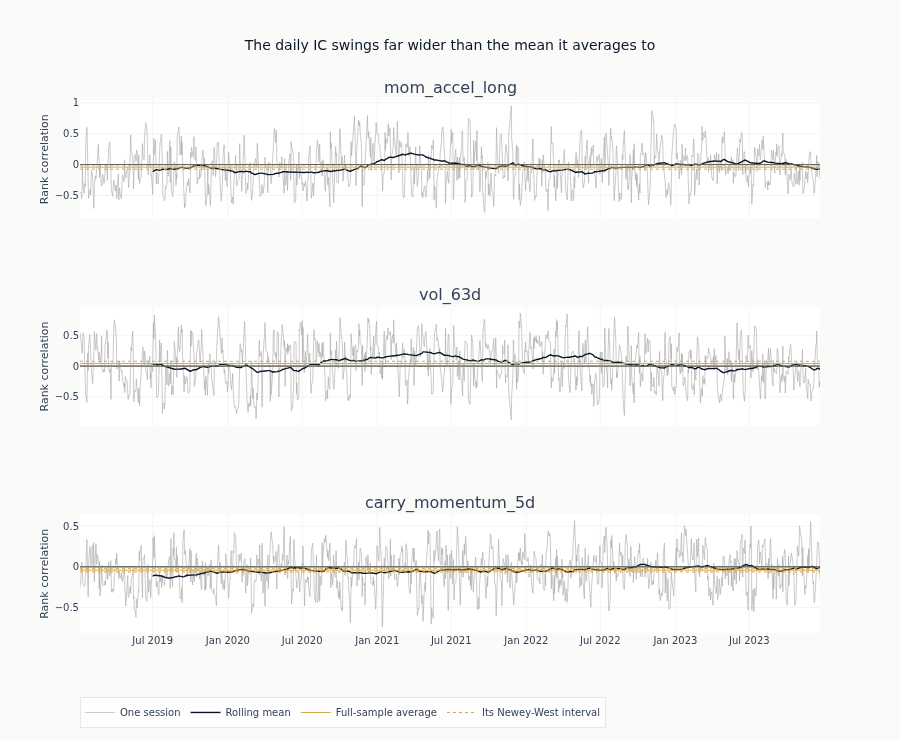

In [14]:
series_features = eval_summary.head(LEADING_FOR_SERIES)["feature"].to_list()

fig = make_subplots(
    rows=len(series_features), cols=1, shared_xaxes=True, subplot_titles=series_features
)
for row, feat in enumerate(series_features, start=1):
    series = ic_timeseries[feat].sort(DATE_COL)
    bands = compute_ic_uncertainty(series, horizon=HAC_MAXLAGS, ic_col="ic")
    dates = series[DATE_COL].to_list()
    fig.add_trace(
        go.Scatter(
            x=dates,
            y=series["ic"].to_list(),
            mode="lines",
            line=dict(color=GRAY_FILLS["muted"], width=0.6),
            name="One session",
            legendgroup="session",
            showlegend=row == 1,
        ),
        row=row,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=dates,
            y=series["ic"].rolling_mean(ROLLING_DAYS, min_samples=ROLLING_DAYS).to_list(),
            mode="lines",
            line=dict(color=COLORS["blue"], width=1.4),
            name="Rolling mean",
            legendgroup="rolling",
            showlegend=row == 1,
        ),
        row=row,
        col=1,
    )
    for value, dash, label, group in (
        (bands["mean_ic"], "solid", "Full-sample average", "mean"),
        (bands["ci_hac_lower"], "dot", "Its Newey-West interval", "band"),
        (bands["ci_hac_upper"], "dot", None, None),
    ):
        fig.add_hline(y=value, line=dict(color=COLORS["amber"], width=1, dash=dash), row=row, col=1)
        if label and row == 1:
            fig.add_trace(
                go.Scatter(
                    x=[dates[0]],
                    y=[value],
                    mode="lines",
                    line=dict(color=COLORS["amber"], width=1, dash=dash),
                    name=label,
                    legendgroup=group,
                ),
                row=row,
                col=1,
            )
    fig.add_hline(y=0, line=dict(color=GRAY_FILLS["border"], width=0.8), row=row, col=1)
fig.update_yaxes(title_text="Rank correlation")
fig.update_layout(
    template="ml4t",
    height=200 * len(series_features) + 140,
    width=900,
    title_text="The daily IC swings far wider than the mean it averages to",
    legend=dict(orientation="h", y=-0.12),
)
fig.show()

### Every feature ranked, with the correction attached

The bars are the average IC, ordered by size, and the number on each is its
Newey-West t-statistic. Colour is one thing throughout this section and the next: the
feature cleared false-discovery control, or it did not. Reading the two together is
the point - a bar can be among the longest and still be uncoloured, which says the
association is large relative to the others and small relative to its own uncertainty.

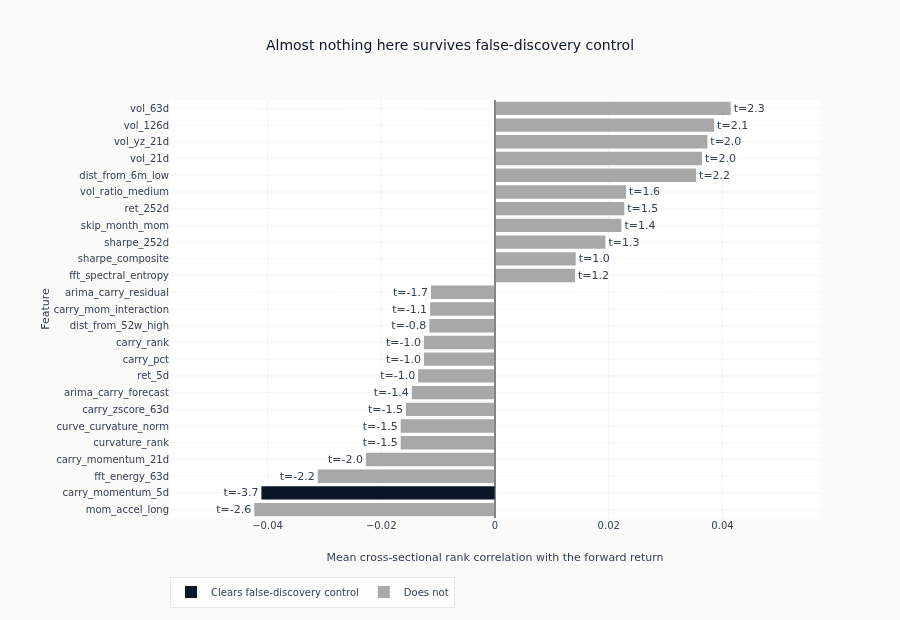

In [15]:
top = eval_summary.head(min(RANKED_SHOWN, len(eval_summary))).sort("ic_mean")

SURVIVES, DOES_NOT = COLORS["blue"], GRAY_FILLS["muted"]

fig = go.Figure(
    go.Bar(
        x=top["ic_mean"].to_list(),
        y=top["feature"].to_list(),
        orientation="h",
        marker_color=[SURVIVES if sig else DOES_NOT for sig in top["fdr_sig"].to_list()],
        text=[f"t={value:.1f}" for value in top["hac_t"].to_list()],
        textposition="outside",
        showlegend=False,
    )
)
for colour, label in ((SURVIVES, "Clears false-discovery control"), (DOES_NOT, "Does not")):
    fig.add_trace(go.Bar(x=[None], y=[None], orientation="h", marker_color=colour, name=label))
fig.add_vline(x=0, line=dict(color=GRAY_FILLS["border"], width=1))
# The t-statistic is drawn past the end of its bar, so the axis needs room beyond the
# longest one or the leftmost label runs into the feature names.
ic_span = max(abs(value) for value in top["ic_mean"].to_list()) * 1.35
fig.update_layout(
    template="ml4t",
    height=620,
    width=900,
    title_text="Almost nothing here survives false-discovery control",
    xaxis_title="Mean cross-sectional rank correlation with the forward return",
    xaxis_range=[-ic_span, ic_span],
    yaxis_title="Feature",
    margin=dict(l=170),
    legend=dict(orientation="h", y=-0.14),
)
fig.show()

### The same features, one window at a time

The average above is drawn over the whole span. This is the same quantity computed
inside each validation window separately: one dot per window, with the middle one
marked. A feature whose dots sit on one side of zero is one the average describes; a
feature whose dots straddle zero has an average that is a compromise between periods
that disagreed. The dots and the marker are produced by the same function the
sign-consistency screen reads, so the marked value is always the middle of the windows
drawn beside it.

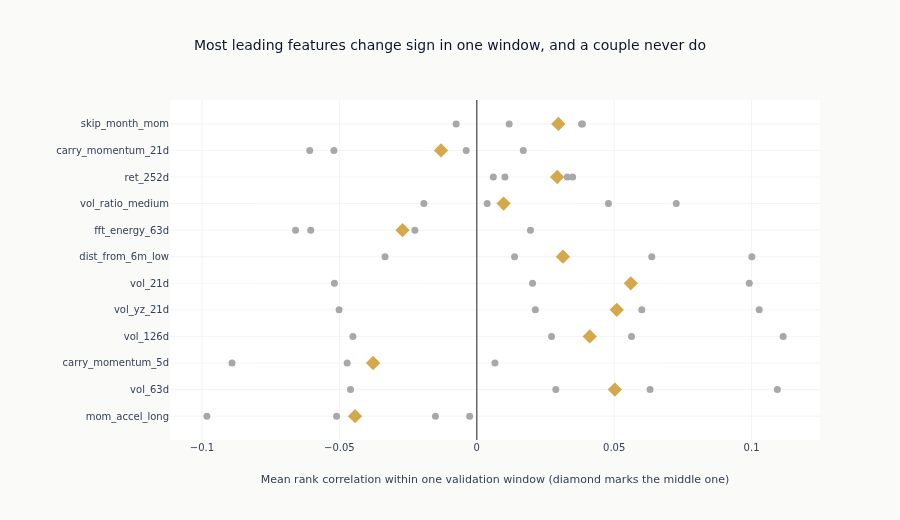

In [16]:
fold_features = [f for f in eval_summary["feature"].to_list() if f in fold_stats][:FOLDS_SHOWN]
fig = go.Figure()
for feat in fold_features:
    per_fold = fold_mean_ics(ic_timeseries[feat])
    fig.add_trace(
        go.Scatter(
            x=per_fold,
            y=[feat] * len(per_fold),
            mode="markers",
            marker=dict(color=GRAY_FILLS["muted"], size=7),
            showlegend=False,
        )
    )
    fig.add_trace(
        go.Scatter(
            x=[fold_stats[feat]["median_fold_ic"]],
            y=[feat],
            mode="markers",
            marker=dict(color=COLORS["amber"], size=11, symbol="diamond"),
            showlegend=False,
        )
    )
fig.add_vline(x=0, line=dict(color=GRAY_FILLS["border"], width=1))
fig.update_layout(
    template="ml4t",
    height=520,
    width=900,
    title_text="Most leading features change sign in one window, and a couple never do",
    xaxis_title="Mean rank correlation within one validation window (diamond marks the middle one)",
    margin=dict(l=170),
)
fig.show()

### What the overlap correction costs

One point per feature: its t-statistic before the correction against its t-statistic
after. The dashed line is where the two agree. A point below it in the upper half, or
above it in the lower half, is a feature whose evidence was overstated by treating
overlapping observations as independent.

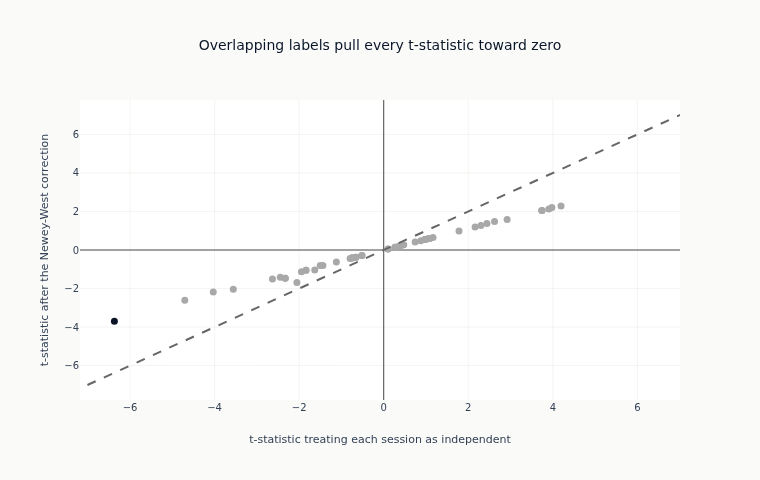

In [17]:
fig = go.Figure(
    go.Scatter(
        x=eval_summary["naive_t"].to_list(),
        y=eval_summary["hac_t"].to_list(),
        mode="markers",
        marker=dict(
            color=[SURVIVES if s else DOES_NOT for s in eval_summary["fdr_sig"].to_list()],
            size=7,
        ),
        text=eval_summary["feature"].to_list(),
        showlegend=False,
    )
)
max_t = (
    max(
        eval_summary["naive_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
        eval_summary["hac_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
    )
    * 1.1
)
fig.add_trace(
    go.Scatter(
        x=[-max_t, max_t],
        y=[-max_t, max_t],
        mode="lines",
        line=dict(dash="dash", color=GRAY_FILLS["border"]),
        showlegend=False,
    )
)
fig.update_layout(
    template="ml4t",
    height=480,
    width=760,
    title_text="Overlapping labels pull every t-statistic toward zero",
    xaxis_title="t-statistic treating each session as independent",
    yaxis_title="t-statistic after the Newey-West correction",
)
fig.show()

The correction moves points toward the horizontal axis, which is what a positive
autocorrelation in the IC series does: the same evidence, counted once instead of
several times. False-discovery control then applies a second penalty for the number of
features tested, and the features drawn in the survivor colour are the ones that clear
both.

### The same features against the other forward horizon

Everything above reads one label. The case study also builds a longer forward return,
and the difference between the two matters for what a strategy could do with a
feature: an association that exists at the weekly horizon and has gone by the monthly
one cannot be held for a month, whatever its average says. Repeating the measurement
at each declared horizon is also what makes the size of the search visible - screening
two horizons and reporting the better one is a search the false-discovery correction
above cannot see, because it was given one set of p-values.

Each horizon is held out of the holdout on its own terms. A longer forward return
settles later, so a session safely inside the development period for the weekly label
can have its monthly label realized inside the holdout. The sessions within one
horizon's reach of the holdout are therefore dropped for that horizon separately,
counted on the panel's own sessions rather than in calendar days.

Two quantities per feature per horizon. The **average IC** is the level. The **IC
information ratio** is that average divided by how much it varies across the
validation windows, which is a per-unit-of-instability reading of the same thing. The
ratio is computed across windows rather than across sessions on purpose: at the longer
horizon consecutive sessions overlap far more, so a session-level ratio would flatter
the longer horizon for a reason that has nothing to do with the feature.

In [18]:
sessions = label_df.select(DATE_COL).unique().sort(DATE_COL).with_row_index("pos")
holdout_pos = sessions.filter(pl.col(DATE_COL) >= HOLDOUT_START)["pos"].min()
assert holdout_pos is not None, "no session on or after the holdout start; cannot seal by position"

leaders = eval_summary.head(HORIZON_SHOWN)["feature"].to_list()
horizon_rows = []
for variant_label, variant_horizon in LABEL_HORIZONS.items():
    # Drop the sessions whose label at this horizon would resolve inside the holdout.
    eligible = sessions.filter(pl.col("pos") < holdout_pos - variant_horizon)[DATE_COL]
    variant = (
        pl.read_parquet(CASE_DIR / "labels" / f"{variant_label}.parquet")
        .filter(pl.col("position") == 0)
        .select([*JOIN_COLS, variant_label])
    )
    joined = (
        eval_panel.select([*JOIN_COLS, *leaders])
        .filter(pl.col(DATE_COL).is_in(eligible.to_list()))
        .join(variant, on=JOIN_COLS, how="inner")
    )
    for feat in leaders:
        valid = joined.select([DATE_COL, "product", feat, variant_label]).drop_nulls()
        series = (
            cross_sectional_ic_series(
                valid.select([DATE_COL, "product", feat]),
                valid.select([DATE_COL, "product", variant_label]),
                pred_col=feat,
                ret_col=variant_label,
                date_col=DATE_COL,
                entity_col="product",
                method="spearman",
                min_obs=MIN_CROSS_SECTION,
            )
            .drop_nulls("ic")
            .filter(pl.col("ic").is_not_nan())
            .sort(DATE_COL)
        )
        if len(series) < MIN_IC_DATES:
            continue
        window_means = fold_mean_ics(series)
        dispersion = float(np.std(window_means, ddof=1)) if len(window_means) > 1 else float("nan")
        horizon_rows.append(
            {
                "feature": feat,
                "horizon": variant_horizon,
                "ic_mean": float(series["ic"].mean()),
                "icir": float(np.mean(window_means)) / dispersion if dispersion else float("nan"),
            }
        )

horizon_ic = pl.DataFrame(horizon_rows)
print(
    f"Horizon profile: {len(leaders)} features across "
    f"{horizon_ic['horizon'].n_unique()} declared forward horizons"
)

Horizon profile: 8 features across 2 declared forward horizons


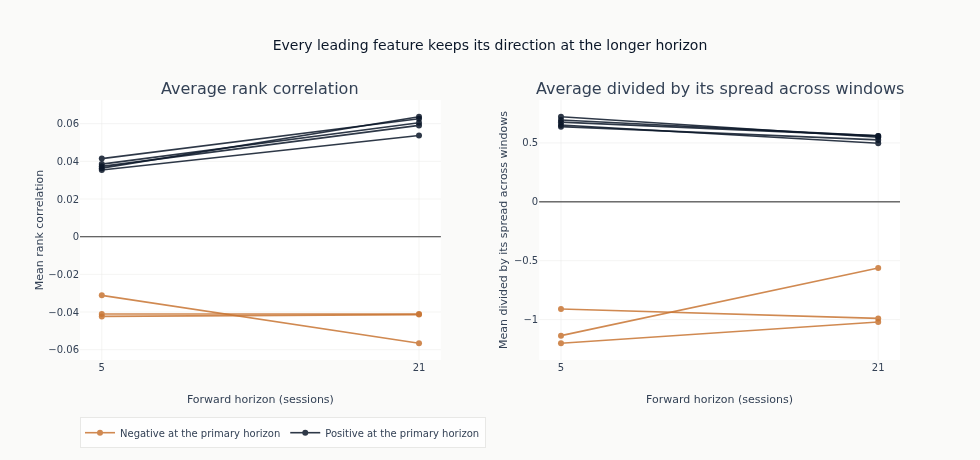

In [19]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Average rank correlation", "Average divided by its spread across windows"),
    horizontal_spacing=0.12,
)
shown_direction = set()
for feat in leaders:
    profile = horizon_ic.filter(pl.col("feature") == feat).sort("horizon")
    if not len(profile):
        continue
    at_primary = profile.filter(pl.col("horizon") == PRIMARY_HORIZON)
    if not len(at_primary):
        continue
    positive = float(at_primary["ic_mean"][0]) > 0
    group = "Positive at the primary horizon" if positive else "Negative at the primary horizon"
    line = dict(color=COLORS["blue"] if positive else COLORS["copper"], width=1.6)
    for column, column_index in (("ic_mean", 1), ("icir", 2)):
        fig.add_trace(
            go.Scatter(
                x=profile["horizon"].to_list(),
                y=profile[column].to_list(),
                mode="lines+markers",
                line=line,
                opacity=0.85,
                name=group,
                legendgroup=group,
                showlegend=column_index == 1 and group not in shown_direction,
                hovertext=feat,
            ),
            row=1,
            col=column_index,
        )
    shown_direction.add(group)
fig.add_hline(y=0, line=dict(color=GRAY_FILLS["border"], width=0.8))
fig.update_layout(
    template="ml4t",
    height=460,
    width=980,
    title_text="Every leading feature keeps its direction at the longer horizon",
    legend=dict(orientation="h", y=-0.22),
)
for column_index in (1, 2):
    fig.update_xaxes(
        title_text="Forward horizon (sessions)",
        tickmode="array",
        tickvals=sorted(LABEL_HORIZONS.values()),
        row=1,
        col=column_index,
    )
fig.update_yaxes(title_text="Mean rank correlation", row=1, col=1)
fig.update_yaxes(title_text="Mean divided by its spread across windows", row=1, col=2)
fig.show()

## 4. What shape is the relationship?

A correlation says a feature and the return move together; it does not say the
relationship is one a model can use in a straight line. This section splits the
products into five buckets by the feature and reads off the average return in each,
from the lowest bucket to the highest. A profile that rises or falls all the way
across is one a single coefficient can carry. One that turns in the middle says the
information is there but a linear model cannot reach it, and a tree-based model in a
later notebook could.

**The buckets are formed inside each session and every session counts once.** The
correlation beside them ranks products against each other on a given day, so the
profile has to be built the same way. Cutting the buckets once over every row of the
panel would sort an observation from one year against one from another and let the
feature's movement over time stand in for its spread across products, which is a
different question with a different answer - and one whose profile could contradict
the correlation it sits next to, with nothing in the notebook to reconcile them.

Two summaries are drawn per bucket. The **mean** is what a book holding every product
in the bucket would earn. The **median** is the typical product. Where they disagree,
the difference is a few large returns rather than the shape of the relationship, and a
rank correlation follows the median.

The panels show the features that cleared false-discovery control first, then the next
largest by absolute correlation, so the figure stays informative when few features
clear it.

In [20]:
fdr_shape = eval_summary.filter(pl.col("fdr_sig").fill_null(False))["feature"].to_list()
top_features_for_shape = (
    fdr_shape + [f for f in eval_summary["feature"].to_list() if f not in fdr_shape]
)[:SHAPE_SHOWN]

QUANTILE_LABELS = [f"Q{i + 1}" for i in range(N_QUANTILES)]

monotonicity_scores = {}
quantile_spreads = {}
for feat in top_features_for_shape:
    valid = eval_panel.select([DATE_COL, feat, label_col]).drop_nulls()
    # A session needs at least one product per bucket before it can be cut into them.
    valid = valid.filter(pl.len().over(DATE_COL) >= N_QUANTILES)
    if valid[DATE_COL].n_unique() < MIN_IC_DATES:
        continue
    binned = valid.with_columns(
        pl.col(feat)
        .qcut(N_QUANTILES, labels=QUANTILE_LABELS, allow_duplicates=True)
        .over(DATE_COL)
        .alias("quantile")
    )
    # Per session first, then across sessions, so every session carries the same
    # weight - which is how the correlation series beside this is built.
    per_date = binned.group_by([DATE_COL, "quantile"]).agg(
        pl.col(label_col).mean().alias("date_mean"),
        pl.col(label_col).median().alias("date_median"),
    )
    profile = (
        per_date.group_by("quantile")
        .agg(
            pl.col("date_mean").mean().alias("mean"),
            pl.col("date_median").mean().alias("median"),
        )
        .sort("quantile")
    )
    means = profile["mean"].to_list()
    medians = profile["median"].to_list()
    quantile_spreads[feat] = {
        "q_means": means,
        "q_medians": medians,
        "spread": means[-1] - means[0],
    }

    # The recorded shape score is the rank correlation between the bucket's position
    # and its mean return: one at a profile that rises all the way across, minus one at
    # one that falls all the way, near zero at one that turns in the middle.
    mono_corr, _ = spearmanr(range(len(means)), means)
    monotonicity_scores[feat] = float(mono_corr)

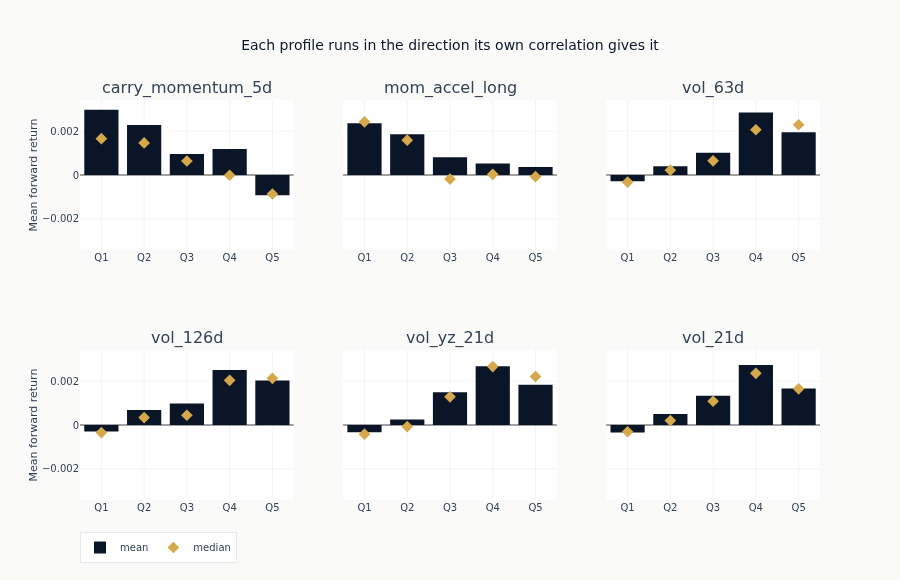

In [21]:
if quantile_spreads:
    n_show = min(SHAPE_SHOWN, len(quantile_spreads))
    feats_to_show = list(quantile_spreads.keys())[:n_show]
    n_rows_fig = (n_show + 2) // 3
    fig = make_subplots(rows=n_rows_fig, cols=3, subplot_titles=feats_to_show, shared_yaxes=True)
    for idx, feat in enumerate(feats_to_show):
        r, c = divmod(idx, 3)
        fig.add_trace(
            go.Bar(
                x=QUANTILE_LABELS,
                y=quantile_spreads[feat]["q_means"],
                marker_color=COLORS["blue"],
                name="mean",
                legendgroup="mean",
                showlegend=idx == 0,
            ),
            row=r + 1,
            col=c + 1,
        )
        fig.add_trace(
            go.Scatter(
                x=QUANTILE_LABELS,
                y=quantile_spreads[feat]["q_medians"],
                mode="markers",
                marker=dict(color=COLORS["amber"], size=9, symbol="diamond"),
                name="median",
                legendgroup="median",
                showlegend=idx == 0,
            ),
            row=r + 1,
            col=c + 1,
        )
    # One y range across the panels: the point of the panels side by side is that their
    # heights are comparable, which independent auto-scaling would destroy.
    span = max(
        abs(value)
        for feat in feats_to_show
        for key in ("q_means", "q_medians")
        for value in quantile_spreads[feat][key]
    )
    fig.update_yaxes(range=[-1.15 * span, 1.15 * span])
    fig.update_yaxes(title_text="Mean forward return", col=1)
    fig.update_layout(
        template="ml4t",
        height=260 * n_rows_fig + 60,
        width=900,
        title_text="Each profile runs in the direction its own correlation gives it",
        legend=dict(orientation="h", y=-0.08),
    )
    fig.show()

Three things to read off these panels. Whether the profile runs all the way across or
turns, which is what decides whether a single coefficient can carry it. Whether it
runs in the direction the feature's correlation implies. It usually will, because both
are formed within the session, but they are different statistics - a profile that is
flat at the ends and turns in the middle can average out either way - so a disagreement
is something to look into rather than a result to accept. And whether the median markers
track the bars: where they do, the shape is a property of the typical product; where a
bar runs well past its marker, that bucket's average is a few large returns.

A profile that climbs to the fourth bucket and gives part of it back at the fifth is
common and is worth separating from a flat one. The information is real, and a linear
coefficient fitted across the ranks has to average the reversal away, while a
tree-based model can isolate the top bucket instead.

## 5. Which candidates are the same evidence twice?

Two features that are nearly the same number under different names do not carry twice
the information, but a screen that tests both counts them as two findings, and a model
fitted on both splits one effect across two coefficients that then move against each
other. This section does two things about that: it groups the features into families
by what they are built from, and it ranks the individual pairs whose correlation is
high enough that they should be read as one piece of evidence.

The grouping is by name, because the names were assigned by construction upstream: a
column built from the term structure carries a term-structure prefix. That makes the
assignment cheap and it makes it brittle in one specific way - a column renamed
upstream falls to the catch-all family, so the catch-all is worth looking at rather
than skipping.

What the families are built from:

- **carry** - the gap between the price of the contract nearest to delivery and the one
  behind it, and how that gap has been moving. Where the near contract trades above the
  deferred one, a long position that rolls forward as delivery approaches moves into a
  cheaper contract whose price then converges upward toward the spot market, and the
  size of the gap is the standard measure of what that is worth. Also here: the
  curvature of the price ladder across the three contracts, which says whether the gap
  widens evenly or bends.
- **momentum** - past returns over various lookbacks, and their rate of change.
- **volatility** - realized variability of the product's own returns, at several
  lookbacks and in ratios between them.
- **sharpe** - a past return divided by the volatility over the same window.
- **technical** - chart quantities such as the relative strength index, distance from
  a moving average, and distance from a running high or low.
- **calendar** - where in the year or in the roll cycle the session falls.
- **temporal_arima**, **temporal_regime**, **temporal_fft** - the three model-derived
  families: a forecast from a fitted time-series model and its error, the probability
  of being in a fitted market state, and quantities read off the frequency content of
  the price series.

In [22]:
def assign_feature_family(name: str) -> str:
    """Map a feature name to the family it was built from."""
    if any(k in name for k in ["carry", "curvature"]):
        return "carry"
    if name.startswith("ret_") or "mom" in name.lower():
        return "momentum"
    if name.startswith("vol_") or name in ("vr_63d",):
        return "volatility"
    if "sharpe" in name:
        return "sharpe"
    if any(name.startswith(p) for p in ["rsi", "ma_ratio", "dist_from", "ts_mom"]):
        return "technical"
    if any(k in name for k in ["month_", "quarter", "roll_", "season", "day_of_year"]):
        return "calendar"
    if any(k in name for k in ["rank", "composite", "ls_signal", "risk_adj"]):
        return "cross_sectional"
    return "other"


families = {feat: assign_feature_family(feat) for feat in all_feature_cols}

# The model-derived columns are grouped by the estimator that produced them instead,
# because what they share is the model, not the price quantity underneath it.
for feat in temporal_cols:
    if "regime" in feat.lower() or "hmm" in feat.lower():
        families[feat] = "temporal_regime"
    elif "fft" in feat.lower() or "spectral" in feat.lower():
        families[feat] = "temporal_fft"
    elif "arima" in feat.lower():
        families[feat] = "temporal_arima"
    else:
        families[feat] = "temporal_other"

The pairwise correlations are taken over a sample of the sessions rather than all of
them. The quantity is a correlation between two feature columns, which changes slowly
over the sample, so a few hundred sessions estimate it as well as every session and at
a fraction of the cost of a full pairwise matrix over the whole panel.

In [23]:
CORRELATION_SAMPLE_SESSIONS = 200
sample_step = max(1, n_dates // CORRELATION_SAMPLE_SESSIONS)
sample_dates = eval_panel[DATE_COL].unique().sort().to_list()[::sample_step]
corr_matrix = (
    eval_panel.filter(pl.col(DATE_COL).is_in(sample_dates))
    .select(evaluable_features)
    .to_pandas()
    .corr(method="spearman")
)

high_corr_pairs = [
    (corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
    for i in range(len(corr_matrix))
    for j in range(i + 1, len(corr_matrix))
    if abs(corr_matrix.iloc[i, j]) > REDUNDANCY_CUT
]
print(
    f"{len(high_corr_pairs)} feature pairs correlate above {REDUNDANCY_CUT:.2f}, "
    f"out of {len(evaluable_features) * (len(evaluable_features) - 1) // 2} pairs"
)

86 feature pairs correlate above 0.70, out of 1431 pairs


### Which families the candidates fall into

One row per family: how many features it contributes, how strong their correlations
are on average, and how many of them cleared false-discovery control. The average
absolute correlation says which family is worth the reader's attention; the signed
average says whether the family points one way or cancels itself out.

In [24]:
fdr_sig_features = set(eval_summary.filter(pl.col("fdr_sig").fill_null(False))["feature"].to_list())
fam_df = (
    pl.DataFrame(
        [
            {
                "feature": feat,
                "family": families.get(feat, "other"),
                "ic": ic_results[feat]["mean_ic"],
                "fdr_sig": feat in fdr_sig_features,
            }
            for feat in ic_results
        ]
    )
    .group_by("family")
    .agg(
        pl.len().alias("n_features"),
        pl.col("ic").abs().mean().alias("avg_abs_ic"),
        pl.col("ic").mean().alias("avg_ic"),
        pl.col("fdr_sig").sum().alias("n_fdr_sig"),
    )
    .sort("avg_abs_ic", descending=True)
)
with pl.Config(tbl_rows=fam_df.height):
    display(fam_df)

family,n_features,avg_abs_ic,avg_ic,n_fdr_sig
str,u32,f64,f64,u32
"""volatility""",7,0.02788,0.022618,0
"""carry""",11,0.014851,-0.013799,1
"""temporal_fft""",4,0.012983,-0.004301,0
"""temporal_arima""",2,0.012943,-0.012943,0
"""momentum""",13,0.011872,0.000204,0
"""technical""",7,0.011358,0.005112,0
"""sharpe""",7,0.008403,0.008403,0


### The strongest pairs

A full correlation matrix over this many features has tick labels too small to read
and is mostly empty space. What has to be decided is which pairs are one piece of
evidence counted twice, so the strongest are ranked instead. The count above the
threshold is printed rather than written into the title, so it cannot go stale.

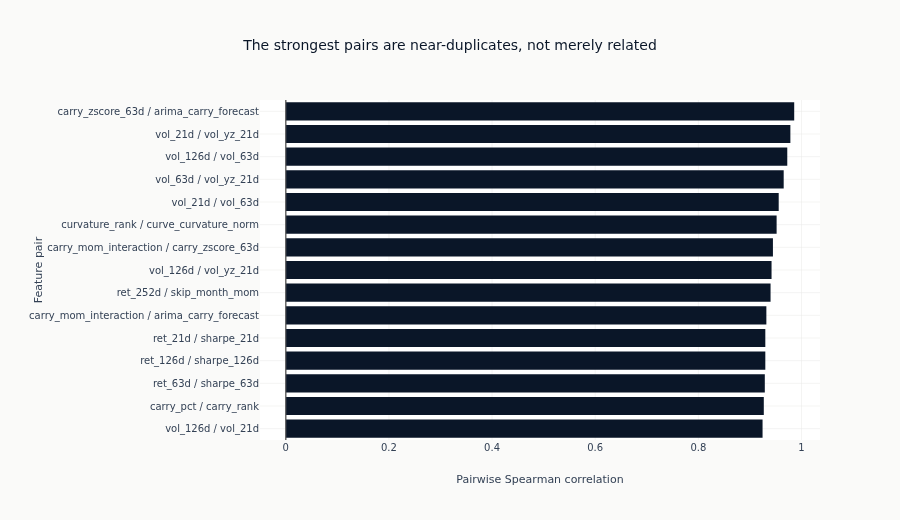

In [25]:
ranked_pairs = sorted(high_corr_pairs, key=lambda item: -abs(item[2]))[:TOP_PAIRS]
if ranked_pairs:
    # Anchored at zero and extended only as far as the pairs actually reach, so a set of
    # pairs that are all one sign does not leave half the axis empty.
    rhos = [rho for _, _, rho in ranked_pairs]
    pair_range = [min(0.0, min(rhos)) - 0.05, max(0.0, max(rhos)) + 0.05]
    fig = go.Figure(
        go.Bar(
            x=[rho for _, _, rho in ranked_pairs][::-1],
            y=[f"{a} / {b}" for a, b, _ in ranked_pairs][::-1],
            orientation="h",
            marker_color=[
                COLORS["blue"] if rho > 0 else COLORS["copper"] for _, _, rho in ranked_pairs
            ][::-1],
            showlegend=False,
        )
    )
    fig.add_vline(x=0, line=dict(color=GRAY_FILLS["border"], width=1))
    fig.update_layout(
        template="ml4t",
        height=520,
        width=900,
        title_text="The strongest pairs are near-duplicates, not merely related",
        xaxis_title="Pairwise Spearman correlation",
        xaxis_range=pair_range,
        yaxis_title="Feature pair",
        margin=dict(l=260),
    )
    fig.show()

**The carry family runs negative over these validation windows, and the screen reports
that rather than resolving it.** The textbook reading of carry says the product whose
nearby contract trades furthest above its deferred contract is the one that pays a long
holder who rolls forward, so a ranking on carry is normally taken long at the top. What
the ranking figure shows over these windows is the opposite sign for the family, and
the strongest member is the five-day change in carry rather than its level - a product
whose carry has just risen did worse over the following week than one whose carry has
just fallen.

Two readings survive this evidence and it does not separate them. Either the premium
is absent or reversed in this universe over this period, or the level and the change
carry different information and a screen that ranks them side by side is mixing two
effects. Nothing here settles it: a univariate correlation over one window and one
horizon is not the instrument for that, and a model with both columns in front of it
is. What the screen owes the reader is that the sign is visible rather than folded
into a ranking on magnitude, which is why the ranking figure is drawn signed.

## 6. One decision per feature

Book Table 7.2's three outcomes, assigned by the rule below.

| Decision | Criteria | Route |
|----------|----------|-------|
| **STOP** | fails the coverage or staleness gate | - |
| **PROCEED** | clears false-discovery control | confirmation |
| **PROCEED** | keeps its own sign in enough validation windows *and* its average correlation clears the floor | exploration |
| **REVISE** | everything else | - |

**The two routes to PROCEED are alternatives, not conditions.** A feature needs one of
them, so the count of features reaching PROCEED can exceed the count that cleared
false-discovery control, and the two populations are not interchangeable. The `note`
column on every row records which route fired, and reading the decision without it
treats a confirmed feature and an unconfirmed one as the same finding.

**The exploration route is a filter, not a test.** Section 7.4 distinguishes an
exploration pass, which promotes on stability rather than on peak significance, from a
confirmation pass. This is the former. It exists because false-discovery control on a
thirty-product cross-section at a weekly cadence will often clear nothing at all, and
a screen that returns an empty shortlist has not told the modelling notebooks anything
about which candidates are worth their compute. Its correlation floor is a judgement
about how weak an association can be and still be worth carrying into a strategy that
pays the cost components `config/setup.yaml` declares for the backtest - commission,
bid-ask spread and roll slippage. There is no conversion from a rank correlation to a
return that would let the floor be computed from those costs, which is exactly why it
is stated rather than derived, and why a feature reaching PROCEED through this route
has not been confirmed by anything.

**REVISE means not ruled out.** It is not a weaker version of PROCEED and not a
rejection: it says this screen found no standalone evidence, and a feature can be
worthless alone and useful in combination with others. Only STOP is a judgement that
the column itself is unusable.

In [26]:
triage = {}
for feat in all_feature_cols:
    if not correctness[feat]:
        triage[feat] = ("STOP", "correctness_fail")
        continue

    if feat not in ic_results:
        triage[feat] = ("REVISE", "insufficient_data")
        continue

    is_fdr_sig = feat in fdr_sig_features
    sign_con = fold_stats.get(feat, {}).get("sign_consistency", 0)
    abs_ic = abs(ic_results[feat]["mean_ic"])

    if is_fdr_sig:
        triage[feat] = ("PROCEED", "fdr_significant")
    elif sign_con >= MIN_SIGN_CONSISTENCY and abs_ic >= IC_THRESHOLD:
        triage[feat] = ("PROCEED", "stable_and_above_threshold")
    else:
        triage[feat] = ("REVISE", "not_significant_standalone")

### The record this notebook hands on

One row per candidate feature, carrying the decision and everything the decision was
made from, so a reader can disagree with the rule without re-running the screen.
`20_strategy_synthesis/02_feature_evaluation` reads this file for all nine case
studies and compares how much each of them found.

The per-session correlation series is written beside it, in long form. It is the raw
object every scalar above summarizes, and it is what the figures in Section 3 are
drawn from.

In [27]:
ledger_rows = []
for feat in all_feature_cols:
    decision, note = triage[feat]
    row = {
        "feature": feat,
        "family": families.get(feat, "other"),
        "source": "temporal" if feat in temporal_cols else "financial",
        "ic_mean": ic_results.get(feat, {}).get("mean_ic"),
        "hac_t": ic_results.get(feat, {}).get("t_stat"),
        "hac_p": ic_results.get(feat, {}).get("p_value"),
        "fdr_p": None,
        "fdr_sig": False,
        "sign_consistency": fold_stats.get(feat, {}).get("sign_consistency"),
        "worst_fold_ic": fold_stats.get(feat, {}).get("worst_fold_ic"),
        "monotonicity": monotonicity_scores.get(feat),
        "coverage": coverage[feat],
        "staleness": staleness[feat],
        "decision": decision,
        "note": note,
    }
    match = eval_summary.filter(pl.col("feature") == feat)
    if len(match) > 0:
        row["fdr_p"] = match["fdr_p"][0]
        row["fdr_sig"] = bool(match["fdr_sig"][0])
    ledger_rows.append(row)

triage_ledger = pl.DataFrame(ledger_rows)
triage_ledger.write_parquet(EVAL_DIR / "triage_ledger.parquet")

ic_ts_all = pl.concat(
    [ts.with_columns(pl.lit(feat).alias("feature")) for feat, ts in ic_timeseries.items()]
)
ic_ts_all.write_parquet(EVAL_DIR / "ic_timeseries.parquet")

print(f"Wrote {display_path(EVAL_DIR / 'triage_ledger.parquet')}, {triage_ledger.height} rows")
print(f"Wrote {display_path(EVAL_DIR / 'ic_timeseries.parquet')}, {ic_ts_all.height} rows")

Wrote case_studies/cme_futures/evaluation/triage_ledger.parquet, 69 rows
Wrote case_studies/cme_futures/evaluation/ic_timeseries.parquet, 65529 rows


### How the decisions divide, and by which route

In [28]:
decision_summary = (
    triage_ledger.group_by("decision", "note")
    .agg(pl.len().alias("n_features"))
    .sort(["decision", "n_features"], descending=[False, True])
)
with pl.Config(tbl_rows=decision_summary.height, fmt_str_lengths=40):
    display(decision_summary)

decision,note,n_features
str,str,u32
"""PROCEED""","""stable_and_above_threshold""",31
"""PROCEED""","""fdr_significant""",1
"""REVISE""","""not_significant_standalone""",19
"""REVISE""","""insufficient_data""",3
"""STOP""","""correctness_fail""",15


**What this screen decided, and how much it is worth.** Few features clear
false-discovery control here, and that is a property of the measurement rather than a
fault in the screen. A rank correlation across thirty products carries little
information on any one session, and the overlapping weekly label means the sessions
are far from independent, so the effective sample behind each average is a fraction of
the number of sessions. A feature has to be strong to clear multiplicity correction
under those conditions.

**Most of what reaches PROCEED gets there by the exploration route.** With five
validation windows, sign consistency takes only six possible values and the bar is
agreement in three of them, which an association with no substance clears about half
the time. So the route rules out a correlation confined to one episode and establishes
nothing beyond that. A reader of the ledger who treats a feature promoted this way as
a finding has been misled by their own summary, which is why the route is recorded per
row.

This notebook does not pronounce on the case study. Screening features one at a time
is necessary and not sufficient, and whether anything here is tradable is decided by a
backtest several notebooks later.

## Key takeaways

1. **State the size of the search next to the p-value.** The three counts above differ
   by a wide margin, and the gap is the price of having tested every feature rather
   than one. A significance claim without the search that produced it cannot be read
   at all, which is why the searched set is printed rather than described.
2. **Measure the association where the feature is out of sample.** Features fitted per
   fold are out of sample only inside their own validation window. Measured over the
   whole development span, their coverage would be whatever share of it the folds
   happen to reach, and the correctness gate would read that design property as a
   broken column. Screening every candidate on the same rows is also what makes the
   ranking a ranking of features rather than of windows.
3. **Judge stability against the feature's own direction.** A feature that is
   consistently negative is as usable as one that is consistently positive, and a rule
   that counts positive windows makes a reliable inverse predictor unpromotable no
   matter what threshold it is given.
4. **Form the buckets the same way the correlation ranks.** Cutting quantiles across
   the pooled panel instead of within each session answers a question about the
   feature over time while the correlation beside it answers one about the feature
   across products, and the two can then appear to corroborate each other while
   disagreeing.
5. **Repeat the measurement at every horizon the case study declares.** Screening two
   horizons and reporting the better one is a search that the multiplicity correction
   was not given and cannot see.
6. **Know what a decision here is worth.** Only STOP says a column is unusable.
   PROCEED through the confirmation route is a finding; PROCEED through the
   exploration route is a candidate; REVISE is neither an endorsement nor a rejection.

**Known limitations.** The screen is univariate, so a feature that carries information
only in combination with another is invisible to it. It reads one label in detail and
the other only at the horizon profile. Sign consistency across five windows is a coarse
statistic. And the correlation floor on the exploration route is a judgement about
costs rather than a quantity estimated from the data, so it is the part of the rule
most worth disagreeing with.

**What reads this.** `20_strategy_synthesis/02_feature_evaluation` (Ch20) loads the
ledger from all nine case studies and compares what each of them found. The modelling
notebooks that follow this one, starting with [`06_linear`](06_linear.ipynb) (Ch11),
load the full feature set through `load_modeling_dataset` and do their own selection
with the model in hand; they do not read this ledger, and the decisions here are a
record of what a univariate screen could establish rather than a filter applied
downstream.